# 15 — Side effects

**The concept:** some steps touch the world outside the pipeline — they write a file, launch a
subprocess, post to an API, send a message. Inside a feedback loop a step runs **once per sweep**.
For a numeric discipline that is how convergence works. For a step that sends an email, it is
thirty emails.

Every other mistake in SmartMDAO is recoverable: you read the finding, fix the model, run it again.
**You cannot un-send an email.** So this is the one place the library refuses rather than warns —
and it asks you to *declare* what a step touches, because it cannot find out on its own.

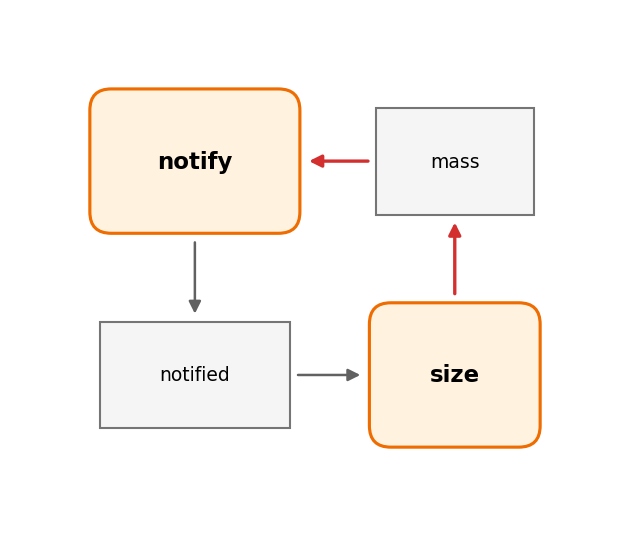

In [1]:
import matplotlib
matplotlib.use("Agg", force=True)

import pathlib, tempfile
from IPython.display import Image
from smartmdao import Pipeline, HybridSolver, IterativeSolver, validate, explain

_gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, inputs, name):
    """Render a pipeline to PNG and display it inline. See notebook 02."""
    path = _gallery / f"{name}.png"
    pipeline.visualize(inputs=inputs, output_path=str(path), view=False)
    return Image(filename=str(path))

def notifying_loop(effects):
    """A sizing loop whose `notify` step 'sends a message' - counted, not sent."""
    sent = []
    pipeline = Pipeline(solver=HybridSolver(max_iterations=80))

    @pipeline.step(outputs=["notified"], effects=effects)
    def notify(mass: float) -> float:
        sent.append(mass)                 # imagine: email.send(...)
        return mass

    @pipeline.step(outputs=["mass"])
    def size(notified: float) -> float:
        return notified * 0.5 + 10.0

    return pipeline, sent

pipeline, _ = notifying_loop(effects=True)
show(pipeline, [], "loop")

`notify` sits on the diagonal with a red feedback arrow back into it: it is inside the loop,
so it will run on every sweep.

## Declaring it

`effects=` sits next to `outputs=`, because it is the same kind of statement — a claim the author
makes about their own function, which the library then reasons about **without running anything**.

| Value | Meaning |
|---|---|
| *absent* | Undeclared; assumed pure |
| `effects=True` | Touches the world — **what should happen in a loop is not stated** |
| `effects="once"` | Run on the first sweep of a `run()`, reuse the result |
| `effects="every-sweep"` | Run every sweep — you meant it |

It is **declared, not inferred**. A step returning `None` looks like a free signal and is not: a step
can write a file *and* return a number.

In [2]:
for finding in validate(pipeline, inputs=[]):
    if finding.code.startswith("side-effect"):
        print(f"[{finding.code}]")
        print(f"  {finding.message}")

[side-effect-in-cycle]
  'notify' declares side effects (effects=True) and would run more than once, because it sits inside a feedback loop, which HybridSolver iterates. run() will refuse it before executing anything. Say which you mean: effects="once" to run on the first sweep and reuse the result, or effects="every-sweep" if repeating is intended.


## `effects=True` in a loop is refused — before anything runs

`validate()` warned about it statically. `run()` goes further and refuses, because a warning printed
next to thirty sent messages is a post-mortem, not information.

In [3]:
from smartmdao import SideEffectError

pipeline, sent = notifying_loop(effects=True)

try:
    pipeline.run(mass=0.0)
except SideEffectError as error:
    print(error)

print()
print("messages sent:", len(sent))

Pipeline execution refused, nothing was run: 'notify' has side effects (effects=True) and would run more than once under HybridSolver, once per sweep. Nothing has been executed. Declare which you want:
    effects="once"        run on the first sweep, reuse the result
    effects="every-sweep" run every time - you meant it
validate() reports this statically as side-effect-in-cycle.


'notify' has side effects (effects=True) and would run more than once under HybridSolver, once per sweep. Nothing has been executed. Declare which you want:
    effects="once"        run on the first sweep, reuse the result
    effects="every-sweep" run every time - you meant it
validate() reports this statically as side-effect-in-cycle.

messages sent: 0


**Zero.** The refusal happens before the solver starts. Nothing stops you proceeding — you just
have to say which behaviour you want.

## `"every-sweep"` — you meant it

In [4]:
pipeline, sent = notifying_loop(effects="every-sweep")
result = pipeline.run(mass=0.0)

print(f"mass = {result['mass']:.4f}   status = {result['convergence_reports'][0].status}")
print(f"messages sent: {len(sent)}")

mass = 20.0000   status = converged
messages sent: 26


## `"once"` — and what it costs

`"once"` executes the step on its first sweep and **reuses that result** for the rest of the run.
One message instead of many. But look at the answer.

In [5]:
pipeline, sent = notifying_loop(effects="once")
latched = pipeline.run(mass=0.0)

print(f"mass = {latched['mass']:.4f}   status = {latched['convergence_reports'][0].status}")
print(f"messages sent: {len(sent)}")
print()
print(f"every-sweep settled at {result['mass']:.4f}; once settled at {latched['mass']:.4f}.")

mass = 10.0000   status = converged
messages sent: 1

every-sweep settled at 20.0000; once settled at 10.0000.


**Both report `converged`. They disagree.**

A step inside a cyclic block feeds the loop back — that is what being in the cycle *means*. So
freezing its output freezes a coupling the loop depends on, and the loop converges against the
first-sweep value instead of its own fixed point. The latch honoured your declaration exactly, and
the answer is still wrong.

`validate()` says so, statically:

In [6]:
for finding in validate(pipeline, inputs=[]):
    if finding.code == "side-effect-latched":
        print(f"[{finding.code}]")
        print(f"  {finding.message}")

[side-effect-latched]
  'notify' is effects="once" and would otherwise repeat, because it sits inside a feedback loop, which HybridSolver iterates. Its output is frozen after the first sweep, so everything downstream in the loop reads the first-sweep value - the loop converges against that, not against its own fixed point, and still reports success. If the effect should happen once but the computation should iterate, split them: a pure step inside the loop, and the side effect on the linear part after it.


## The real fix: keep the loop pure, put the effect after it

If the effect should happen once but the computation should iterate, **split the step**. The pure
part stays in the loop; the side effect moves to the linear part, downstream, where it runs exactly
once on the converged result. This is the same *decide → evaluate completely → act* shape
[12 — Rule-backed disciplines](12-rule-backed-disciplines.ipynb) recommends for decisions.

In [7]:
sent = []
split = Pipeline(solver=HybridSolver(max_iterations=80))

@split.step(outputs=["relayed"])
def relay(mass: float) -> float:                   # pure: stays in the loop
    return mass

@split.step(outputs=["mass"])
def size_again(relayed: float) -> float:
    return relayed * 0.5 + 10.0

@split.step(outputs=["receipt"], effects=True)     # the effect, AFTER the loop
def notify_once(mass: float) -> str:
    sent.append(mass)
    return f"sent for {mass:.2f}"

out = split.run(mass=0.0)
print(f"mass = {out['mass']:.4f}   ({out['receipt']})")
print(f"messages sent: {len(sent)}")
print("findings:", [f.code for f in validate(split, inputs=["mass"])] or "none")

mass = 20.0000   (sent for 20.00)
messages sent: 1
findings: none


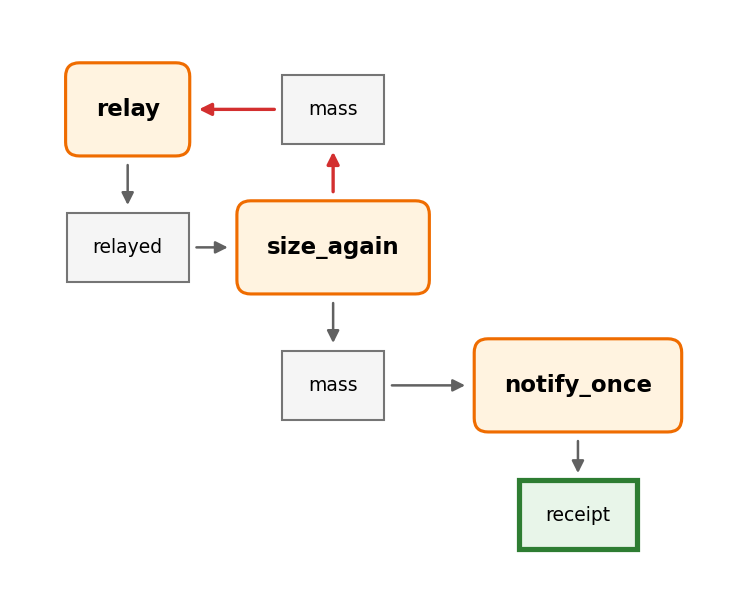

In [8]:
show(split, ["mass"], "split")

The right answer (20), one message, no findings — and the diagram shows why: `notify_once` sits
below the loop with no arrow back into it.

## "Would it repeat" is not "is it in a cycle"

`IterativeSolver` sweeps **every** step it was given, whether or not there is a loop. So an acyclic
pipeline still repeats, and is still refused.

In [9]:
straight = Pipeline(solver=IterativeSolver(max_iterations=5))

@straight.step(outputs=["y"], effects=True)
def post(x: float) -> float:
    return x

try:
    straight.run(x=1.0)
except SideEffectError as error:
    print(str(error).splitlines()[0])

Pipeline execution refused, nothing was run: 'post' has side effects (effects=True) and would run more than once under IterativeSolver, once per sweep. Nothing has been executed. Declare which you want:
    effects="once"        run on the first sweep, reuse the result
    effects="every-sweep" run every time - you meant it
validate() reports this statically as side-effect-in-cycle.


'post' has side effects (effects=True) and would run more than once under IterativeSolver, once per sweep. Nothing has been executed. Declare which you want:


## Anything that multiplies runs refuses by default

`"once"` is scoped to **one** `run()`. An optimizer calls `run()` once per evaluation — hundreds of
times — so no per-run latch can help there. `PipelineEvaluator` refuses a pipeline with **any**
declared effect unless you pass `allow_effects=True`.

In [10]:
from smartmdao import PipelineEvaluator

pipeline, sent = notifying_loop(effects="once")

try:
    PipelineEvaluator(pipeline, design_vars=["mass"])
except SideEffectError as error:
    print(error)

print()
evaluator = PipelineEvaluator(pipeline, design_vars=["mass"], allow_effects=True)
for point in ([0.0], [5.0], [9.0]):
    evaluator.evaluate(point)
print(f"with allow_effects=True, three evaluations sent {len(sent)} messages")

'notify' ('once') declares side effects. An optimizer runs the pipeline once per evaluation, typically hundreds of times - and effects="once" is scoped to a single run, so it would still fire every time. Nothing has been executed. Pass allow_effects=True if that is intended.

with allow_effects=True, three evaluations sent 3 messages


The same rule applies to `compare_runs`, which executes **both** files — so every side effect
would run twice:

In [11]:
from smartmdao.mcp.handlers import compare_runs

workspace = pathlib.Path(tempfile.mkdtemp())
model = workspace / "notifier.py"
model.write_text(
    "from smartmdao import Pipeline\n"
    "\n"
    "def build_pipeline() -> Pipeline:\n"
    "    pipeline = Pipeline()\n"
    "\n"
    "    @pipeline.step(outputs=['y'], effects='every-sweep')\n"
    "    def send(x: float) -> float:\n"
    "        return x\n"
    "\n"
    "    return pipeline\n"
)

refused = compare_runs(str(model), str(model), inputs={"x": 1.0})
print("ok:     ", refused["ok"])
print("refused:", refused["refused"])
print()
print("with allow_effects=True ->", compare_runs(str(model), str(model), inputs={"x": 1.0},
                                                  allow_effects=True)["match"])

ok:      False
refused: side-effects



with allow_effects=True -> True


## Analysing a file does not run it

The MCP tools take a *path*, so they have to import the file — and importing a script runs its
top-level code. A bare `pipeline.run(...)` at module level used to execute the whole study every
time the file was analysed. It no longer does: execution is suspended while a file is loaded.

In [12]:
from smartmdao.mcp.handlers import validate_pipeline, analyze_pipeline

log = workspace / "sent.log"
script = workspace / "script.py"
script.write_text(
    "import pathlib\n"
    "from smartmdao import Pipeline\n"
    "\n"
    "pipeline = Pipeline()\n"
    "\n"
    "@pipeline.step(outputs=['y'], effects='once')\n"
    "def send(x: float) -> float:\n"
    f"    pathlib.Path({str(log)!r}).open('a').write('sent\\n')\n"
    "    return x\n"
    "\n"
    "pipeline.run(x=1.0)   # bare, at module level\n"
)

validate_pipeline(str(script))
analyze_pipeline(str(script))
print("messages sent by two static analyses:", log.read_text().count("sent") if log.exists() else 0)

messages sent by two static analyses: 0


## `explain()` lists what a pipeline touches

"What does this touch outside itself?" is exactly what a reviewer wants stated, so it is.

In [13]:
for line in explain(split, inputs=["mass"]).splitlines():
    if "Touches" in line or "notify_once" in line:
        print(line)

Pipeline with 3 step(s): relay, size_again, notify_once.
Execution order: relay -> size_again -> notify_once
Touches the world (1):
  notify_once: unspecified in a loop


## What this does not guarantee

A declaration is a **claim**. Nothing checks that a step marked pure is pure, and nothing could in
general. This layer improves on silence, not on certainty: a pipeline with no declarations is not a
pipeline with no side effects, it is a pipeline nobody has annotated.

A typo in the declaration raises rather than being reported — `effects="sometimes"` would silently
declare a destructive step pure.

In [14]:
try:
    Pipeline().add(lambda x: x, outputs=["y"], effects="sometimes")
except ValueError as error:
    print(error)

effects must be one of [None, False, True, 'once', 'every-sweep'], got 'sometimes'. A typo here would silently declare a destructive step pure, so it is refused rather than reported.


In [15]:
import shutil
shutil.rmtree(_gallery); shutil.rmtree(workspace)
print("cleaned up")

cleaned up


---

**Next:** [16 — Pitfalls](16-pitfalls.ipynb).